In [1]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import os, json, warnings
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import joblib

import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Dropout, BatchNormalization,
    Bidirectional, RepeatVector, TimeDistributed,
    Reshape
)
from tensorflow.keras.layers import Lambda

import tensorflow as tf
from tensorflow.keras.layers import Lambda
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Reproducibility ──
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Plot style ──
plt.rcParams.update({
    "figure.dpi"       : 120,
    "figure.facecolor" : "white",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
})
sns.set_palette("husl")

# ── Paths ──
DATA_PATH  = "../data/processed/azamgarh_weather_final1.csv"
MODEL_DIR  = "../models/lstm1"
SCALER_DIR = "../models/scalers1"
os.makedirs(MODEL_DIR,  exist_ok=True)
os.makedirs(SCALER_DIR, exist_ok=True)

# ── Key hyperparameters (change these freely) ──
LOOKBACK    = 24    # hours of past data to look at
FORECAST_N  = 5     # hours to predict into future (change to any N)
BATCH_SIZE  = 32
EPOCHS      = 100   # early stopping will kick in before this
TARGET_COL  = "temperature"

print(f"✅  TensorFlow version : {tf.__version__}")
print(f"    Lookback window    : {LOOKBACK} hours")
print(f"    Forecast horizon   : {FORECAST_N} hours")
print(f"    Target column      : {TARGET_COL}")


✅  TensorFlow version : 2.21.0
    Lookback window    : 24 hours
    Forecast horizon   : 5 hours
    Target column      : temperature


In [9]:
df = pd.read_csv(DATA_PATH, parse_dates=["valid_time"])
df = df.sort_values("valid_time").reset_index(drop=True)

print(f"Shape      : {df.shape}")
print(f"Date range : {df['valid_time'].min()} → {df['valid_time'].max()}")
print(f"Missing    :\n{df.isnull().sum()[df.isnull().sum() > 0]}")
df.head()


Shape      : (8736, 18)
Date range : 2025-01-02 00:00:00 → 2025-12-31 23:00:00
Missing    :
Series([], dtype: int64)


,valid_time,temperature,surface_pressure,total_cloud_cover,low_cloud_cover,medium_cloud_cover,high_cloud_cover,precipitation,humidity,wind_speed,hour,day,month,day_of_week,temp_rolling_6,temp_lag_1,temp_lag_24,rain_tomorrow
0,2025-01-02 00:00:00,10.243958,1007.98110,0.000000,0.000000,0.0,0.000000,0.0,91.275276,1.957509,0,2,1,3,9.957026,9.754242,12.305115,0
1,2025-01-02 01:00:00,10.034027,1008.83620,0.000000,0.000000,0.0,0.000000,0.0,91.548195,1.777704,1,2,1,3,9.885452,10.243958,12.614502,0
2,2025-01-02 02:00:00,10.117249,1009.32810,0.015259,0.015259,0.0,0.000000,0.0,89.642296,2.108368,2,2,1,3,9.903219,10.034027,12.506287,0
3,2025-01-02 03:00:00,10.726746,1010.08950,0.000000,0.000000,0.0,0.000000,0.0,86.600450,1.495689,3,2,1,3,10.073166,10.117249,12.865356,0
4,2025-01-02 04:00:00,11.140686,1010.74615,0.082397,0.048828,0.0,0.033569,0.0,85.779330,1.550697,4,2,1,3,10.336151,10.726746,12.227509,0


In [10]:
# Basic stats for temperature
print("── Temperature Statistics ──")
print(df[TARGET_COL].describe().round(2))
print(f"\nHourly frequency check (should be ~1h gaps):")
time_diffs = df["valid_time"].diff().dropna()
print(time_diffs.value_counts().head(3))


── Temperature Statistics ──
count    8736.00
mean       25.47
std         7.23
min         7.56
25%        20.36
50%        27.35
75%        30.56
max        42.91
Name: temperature, dtype: float64

Hourly frequency check (should be ~1h gaps):
valid_time
0 days 01:00:00    8735
Name: count, dtype: int64


TypeError: Axes.boxplot() got an unexpected keyword argument 'labels'. Did you mean 'label'?

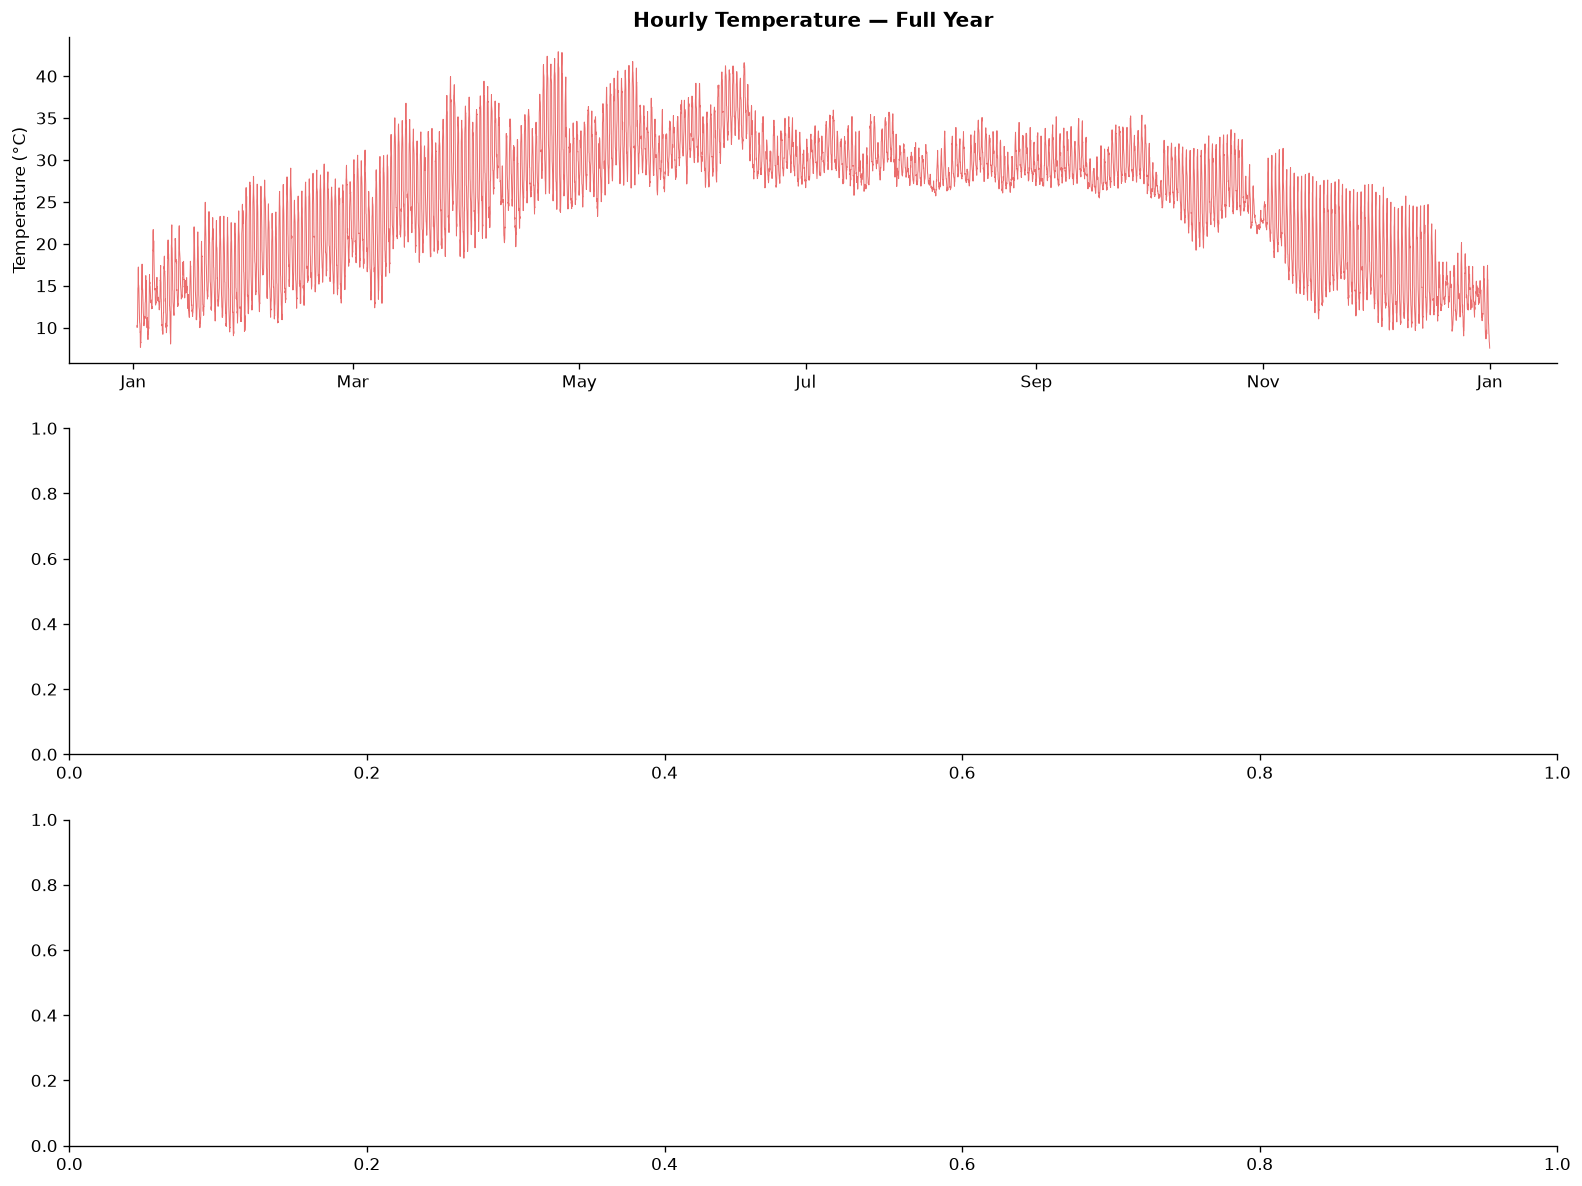

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Full year temperature
axes[0].plot(df["valid_time"], df[TARGET_COL], lw=0.6, color="#E85D5D", alpha=0.9)
axes[0].set_title("Hourly Temperature — Full Year", fontweight="bold")
axes[0].set_ylabel("Temperature (°C)")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b"))

# Monthly boxplot
months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
monthly_data = [df[df["valid_time"].dt.month == m][TARGET_COL].values for m in range(1,13)]
bp = axes[1].boxplot(monthly_data, patch_artist=True)
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(months)
colors = plt.cm.RdYlBu_r(np.linspace(0, 1, 12))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
axes[1].set_title("Monthly Temperature Distribution", fontweight="bold")
axes[1].set_ylabel("Temperature (°C)")

# Diurnal pattern (avg temp per hour of day)
df["hour_of_day"] = df["valid_time"].dt.hour
hourly_avg = df.groupby("hour_of_day")[TARGET_COL].mean()
axes[2].plot(hourly_avg.index, hourly_avg.values, "o-", color="#4A90D9", lw=2, ms=5)
axes[2].fill_between(hourly_avg.index, hourly_avg.values, alpha=0.15, color="#4A90D9")
axes[2].set_title("Average Diurnal Pattern (Hour of Day)", fontweight="bold")
axes[2].set_ylabel("Avg Temperature (°C)")
axes[2].set_xlabel("Hour of Day")
axes[2].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/eda_temperature.png", bbox_inches="tight")
plt.show()
